# **Największe skojarzenie w grafach dwudzielnych**

#Problem: Należy dobrać w pary do poloneza n kobiet i n mężczyzn, gdzie każda z kobiet jest skłonna zatańczyć poloneza z jednym z k mężczyzn.

Niech wierzchołkami grafu będą kobiety i mężczyźni. Krawędzie natomiast niech określają preferencje poszczególnych panien co do swojego partnera tanecznego. Zakładamy, że pary do poloneza nie mogą być jednopłciowe. Dlatego nie ma połączeń pomiędzy kobietami, ani pomiędzy mężczyznami. W ten sposób powstaje graf dwudzielny.


#Przykład
Mamy 5 kobiet:  Agata, Basia, Celina, Dorota, Ewa

oraz 5 mężczyzn:  Franek, Grzesiek, Hubert, Igor, Jasiek.

Preferencje każdej z kobiet są następujące:

Agata → Franek, Hubert

Basia → Franek, Grzesiek

Celina → Grzesiek, Igor

Dorota → Hubert, Jasieko

Ewa → Igor

Przejdźmy teraz do algorytmu kojarzenia par do poloneza.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

kobiety = {"A": "Agata", "B": "Basia", "C": "Celina", "D": "Dorota", "E": "Ewa"}
mezczyzni = {"F": "Franek", "G": "Grzesiek", "H": "Hubert", "I": "Igor", "J": "Jasiek"}


#Preferencje kobiet w postaci grafu
graph = {
    "A": ["F", "H"],
    "B": ["F", "G"],
    "C": ["G", "I"],
    "D": ["H", "J"],
    "E": ["I"]}

Narysujemy teraz graf przedstawiający preferencje kobiet co do swojego potencjalnego partnera do poloneza.

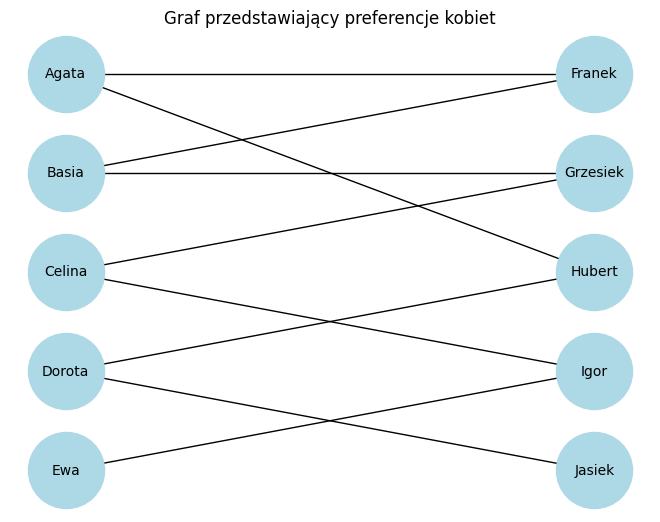

In [ ]:
G = nx.Graph()    # tworzy pusty graf nieskierowany

for kobieta_id, name in kobiety.items():          # w każdej iteracji kobieta_id dostaje numer, name dostaje imię
    G.add_node(kobieta_id, label=name, bipartite=0)   # dodaje wierzchołek do grafu

for mezczyzna_id, name in mezczyzni.items():
    G.add_node(mezczyzna_id, label=name, bipartite=1)


for kobieta, preferencje in graph.items():
    for mezczyzna in preferencje:
        G.add_edge(kobieta, mezczyzna)      # dodawanie krawędzi


pos = {}      # tworzy pusty słownik, który będzie przechowywać współrzędne (x,y)

for i, kobieta in enumerate(kobiety):
    pos[kobieta] = (0, -i)    # 0 oznacza, że kobiety będą po lewej

for i, mezczyzna in enumerate(mezczyzni):
    pos[mezczyzna] = (1, -i)    # 1 oznacza, że mężczyźni będą po prawej

nx.draw(G, pos, with_labels=True, labels={**kobiety, **mezczyzni}, node_color="lightblue", node_size=3000, font_size=10)

plt.title("Graf przedstawiający preferencje kobiet")
plt.show()



# Celem algorytmu jest znalezienie maksymalnego skojarzenia, czyli takiego zestawu par, w którym liczba dopasowań jest jak największa przy danych ograniczeniach, czyli preferencjach.

In [ ]:
def najw_skojarzenie(graph):
    dopasowani_mezczyzni = {}

    def pary(kobieta, visited):     # kobieta oznacza dla kogo szukamy pary, a visited których mężczyzn już sprawdziliśmy
        for mezczyzna in graph[kobieta]:
            if mezczyzna in visited:
                continue
            visited.add(mezczyzna)      # dodajemy mężczyznę do zbioru odwiedzonych
            if mezczyzna not in dopasowani_mezczyzni or pary(dopasowani_mezczyzni[mezczyzna], visited):
                dopasowani_mezczyzni[mezczyzna] = kobieta   # próba znalezienia innej pary dla obecnej partnerki
                return True       # udało się znaleźć nowego partnera
        return False      # nie udało się znaleźć nowego partnera

    def udane_dopasowania():
        result = 0
        for kobieta in graph:
            visited = set()
            if pary(kobieta, visited):
                result += 1
        return result, dopasowani_mezczyzni

    return udane_dopasowania()


liczba, dopasowanie = najw_skojarzenie(graph)
print("Liczba dopasowanych par:", liczba)
print("\nPary:")
for m, k in dopasowanie.items():
    print(kobiety[k], "→", mezczyzni[m])




Liczba dopasowanych par: 5

Pary:
Basia → Franek
Agata → Hubert
Celina → Grzesiek
Ewa → Igor
Dorota → Jasiek


Poniżej mamy przykład, w którym nie da się dobrać partnera dla każdej kobiety.

In [ ]:
graph2 = {
    "A": ["F", "G"],
    "B": ["F", "H"],
    "C": ["G", "F"],
    "D": ["I", "J"],
    "E": ["G"]
}

liczba2, dopasowanie2 = najw_skojarzenie(graph2)
print("Liczba dopasowanych par:", liczba2)
print("\nPary:")
for m, k in dopasowanie2.items():
    print(kobiety[k], "→", mezczyzni[m])

Liczba dopasowanych par: 4

Pary:
Agata → Franek
Celina → Grzesiek
Basia → Hubert
Dorota → Igor


# Wnioski
Algorytm największego skojarzenia pozwala dobrać maksymalną możliwą liczbę par przy zadanych preferencjach.

Nie zawsze da się utworzyć parę dla każdej osoby, ponieważ wszystko zależy od liczby i układu preferencji.

Jeśli kilka kobiet wybiera tego samego mężczyznę, może dojść do konfliktu i część osób pozostanie bez partnera.



# Przykład z preferencjami kobiet i mężczyzn



In [ ]:

kobiety_pref = {
    "A": ["G", "I", "J"],
    "B": ["G", "H", "J"],
    "C": ["H", "J"],
    "D": ["F", "H"],
    "E": ["F", "H", "I"]}

mezczyzni_pref = {
    "F": ["A", "D", "E"],
    "G": ["A", "B", "C"],
    "H": ["B", "C", "D", "E"],
    "I": ["A", "C"],
    "J": ["A", "B", "D"]}

dopasowani_mezczyzni = {}

graph3 = {          # do każdej kobiety dokładadmy tylko tych mężczyzn, których ona chce i którzy też chcą ją w swoich preferencjach
k: [m for m in kobiety_pref[k] if k in mezczyzni_pref[m]]
    for k in kobiety_pref}

print(graph3)
print()

liczba3, dopasowanie3 = najw_skojarzenie(graph3)
print("Liczba dopasowanych par:", liczba3)
print("\nPary:")
for m, k in dopasowanie3.items():
    print(kobiety[k], "→", mezczyzni[m])

{'A': ['G', 'I', 'J'], 'B': ['G', 'H', 'J'], 'C': ['H'], 'D': ['F', 'H'], 'E': ['F', 'H']}

Liczba dopasowanych par: 4

Pary:
Basia → Grzesiek
Agata → Igor
Celina → Hubert
Dorota → Franek


# Szczegółowy opis działania algorytmu

Funkcja najw_skojarzenie(graph) to algorytm znajdowania maksymalnego skojarzenia w grafie dwudzielnym, czyli dopasowania kobiet do mężczyzn na podstawie ich preferencji.

Na początku tworzony jest pusty słownik dopasowani_mezczyzni, który będzie przechowywał aktualne dopasowanie w formie klucz to mężczyzna, a wartość to kobieta, z którą jest aktualnie sparowany.

Następnie w środku funkcji definiowana jest funkcja rekurencyjna pary(kobieta, visited), która próbuje znaleźć partnera dla danej kobiety. Funkcja ta przegląda wszystkich mężczyzn dostępnych dla tej kobiety w grafie graph[kobieta]. Dla każdego mężczyzny sprawdza najpierw, czy znajduje się w zbiorze visited. Jeśli tak, to jest pomijany, aby uniknąć zapętlenia i wielokrotnego sprawdzania tego samego wyboru.

Jeśli mężczyzna nie był jeszcze odwiedzony, zostaje dodany do visited, co oznacza, że w tej ścieżce próbujemy go dopasować.

Następnie algorytm sprawdza dwa przypadki. Pierwszy, czy ten mężczyzna nie ma jeszcze przypisanej kobiety (mezczyzna not in dopasowani_mezczyzni). Jeśli nie ma, to można go od razu przypisać do aktualnej kobiety i zwrócić True, bo znaleziono dopasowanie.

Drugi przypadek zachodzi wtedy, gdy mężczyzna już jest zajęty. Wtedy algorytm próbuje zamienić jego obecną partnerkę na innego mężczyznę. Jeśli uda się znaleźć alternatywę dla jego obecnej partnerki, to zwalnia się miejsce i można przypisać tego mężczyznę do nowej kobiety.

Jeżeli żaden mężczyzna z listy nie może zostać przypisany ani bezpośrednio, ani przez zamiane par, funkcja zwraca False, co oznacza, że dla tej kobiety nie udało się znaleźć partnera.

Druga funkcja wewnętrzna udane_dopasowania() przechodzi po wszystkich kobietach w grafie i dla każdej z nich próbuje znaleźć dopasowanie, tworząc za każdym razem nowy pusty zbiór visited. Dzięki temu każda próba dopasowania jest niezależna. Jeśli pary() zwróci True, oznacza to, że udało się znaleźć lub poprawić dopasowanie, więc licznik result jest zwiększany o 1.

Na końcu udane_dopasowania() zwraca dwie rzeczy, liczbę udanych dopasowań oraz końcowy słownik dopasowani_mezczyzni, który zawiera pełny wynik skojarzeń po zakończeniu działania algorytmu.

Ostatecznie funkcja najw_skojarzenie(graph) zwraca liczbę udanych dopasować oraz jakie dokładnie pary zostały utworzone.

In [ ]:
from collections import deque

def MaximumMatching(G, X, Y, M):
    U = set(X) - set(M.values())   # X \ M_X czyli  zbiór nienasyconych wierzchołków z X
    while True:
        S = set(U)
        T = set()       # "kapryśne" wierzchołki z X i "wszechstronne" z Y
        a = 0           # poprawa
        pop = {}        # poprzedniki
        kol = deque()   # kolejka
        for u in U:
            kol.append(u)
        while kol:
            u = kol.popleft()
            for v in G[u]:
                if v in T:
                    continue
                if v in M:        # v zajęty to przedłużamy ścieżkę powiększającą
                    pop[v] = u
                    x = M[v]
                    kol.append(x)
                    S.add(x)
                    T.add(v)
                else:             # v wolny to powiększamy skojarzenie
                    x = u
                    while x in M.values():
                        y = None
                        for mm, xx in M.items():
                            if xx == x:
                                y = mm
                                break
                        M[v] = x
                        x = pop[y]
                        v = y
                    M[v] = x
                    U.remove(x)
                    a = 1
                    break
            if a == 1:
                kol.clear()       #po poprawce czyścimy kolejke, żeby zacząć od nowa
        if a == 0:
            break
    Q = T.union(set(X) - S)
    return M, Q

# Szczegółowy opis działania algorytmu
Funkcja MaximumMatching(G, X, Y, M) realizuje znajdowanie maksymalnego skojarzenia w grafie dwudzielnym, czyli próbuje jak najlepiej dopasować wierzchołki z jednej części zbioru (X - kobiety) do wierzchołków z drugiej części (Y - mężczyźni), tak aby żadna para nie nakładała się na siebie.

Na początku algorytm wyznacza zbiór U, który zawiera wszystkie nienasycone wierzchołki z części X, czyli takie, które nie jest połączone z żadną krawędzią w aktualnym skojarzeniu M. Te wierzchołki stanowią punkty startowe do dalszego przeszukiwania.

Następnie algorytm wchodzi w pętlę, w której próbuje znaleźć ścieżki powiększające, czyli takie ścieżki, które zaczynają się w wolnym wierzchołku z X i kończą w wolnym wierzchołku z Y. W tym celu tworzone są struktury pomocnicze S i T, które przechowują odpowiednio odwiedzone wierzchołki po stronie X i Y, oraz słownik pop, który zapamiętuje poprzedników na ścieżkach, co później pozwala odtworzyć znalezione połączenia. Dodatkowo używana jest kolejka kol, która realizuje przeszukiwanie wszerz, zaczynając od wszystkich wierzchołków z U.

W trakcie przeszukiwania wszerz algorytm pobiera kolejny wierzchołek u i sprawdza jego sąsiadów v w grafie G. Jeśli dany sąsiad v został już odwiedzony po stronie Y (czyli należy do zbioru T), to jest pomijany. Jeśli natomiast v jest już skojarzony (czyli istnieje w M), to algorytm „przechodzi dalej” przez jego partnera x = M[v], dodając go do kolejki i zapisując, że doszliśmy do niego przez u.

Jeżeli jednak algorytm natrafi na wierzchołek v, który nie jest skojarzony, oznacza to, że znaleziono ścieżkę powiększającą. Wtedy rozpoczyna się etap jej wykorzystania, skojarzenie jest „przepinane” wzdłuż tej ścieżki, czyli wcześniejsze dopasowania są odwracane, a nowe pary są tworzone. W efekcie liczba skojarzeń zwiększa się o jeden. Po wykonaniu tej operacji przeszukiwanie wszerz jest przerywany i algorytm wraca do początku, aby szukać kolejnych możliwych ulepszeń dopasowania.

Pętla główna działa dopóki w danej iteracji uda się znaleźć choć jedną ścieżkę powiększającą. Jeśli żadnej takiej ścieżki nie da się już znaleźć, algorytm kończy działanie, ponieważ oznacza to, że osiągnięto maksymalne skojarzenie.

Na końcu funkcja zwraca końcowe skojarzenie M oraz zbiór Q czyli minimalne pokrycie wierzchołkowe.

In [ ]:
M = {}

graph4 = {
    "A": ["F", "G"],
    "B": ["F", "G"],
    "C": ["F", "G"],
    "D": ["H"],
    "E": ["H"]}

M, Q = MaximumMatching(graph4, set(kobiety.keys()), set(mezczyzni.keys()), M)   # set(kobiety.keys()) - zwraca zbiór kluczy {"A","B","C","D,"E"}

print("Maksymalne skojarzenie:")
for m, k in M.items():
    print(kobiety[k], "→", mezczyzni[m])
print("\nMinimalne pokrycie wierzchołkowe:")
for v in Q:
    if v in kobiety:
        print(kobiety[v])
    else:
        print(mezczyzni[v])

Maksymalne skojarzenie:
Basia → Franek
Ewa → Hubert
Celina → Grzesiek

Minimalne pokrycie wierzchołkowe:
Hubert
Grzesiek
Franek


Algorytm MaximumMatching pozwala nie tylko znaleźć maksymalne skojarzenie, ale również wyznaczyć minimalne pokrycie wierzchołkowe. Rozmiar minimalnego pokrycia wierzchołkowego zawsze jest równy rozmiarowi maksymalnego skojarzenia.

In [ ]:
liczba4, dopasowanie4 = najw_skojarzenie(graph4)
print("Liczba dopasowanych par:", liczba4)
print("\nPary:")
for m, k in dopasowanie4.items():
    print(kobiety[k], "→", mezczyzni[m])

Liczba dopasowanych par: 3

Pary:
Basia → Franek
Agata → Grzesiek
Dorota → Hubert


**Porównanie obu podejść**

Oba zastosowane podejścia do problemu maksymalnego skojarzenia w grafie dwudzielnym dały różne wyniki w sensie konkretnych dopasowań, jednak liczba uzyskanych par jest taka sama i wynosi 3. W przypadku algorytmu MaximumMatching otrzymano skojarzenie:

Celina → Franek,

Dorota → Hubert

Agata → Grzesiek,

natomiast funkcja najw_skojarzenie zwróciła:

Basia → Franek,

Agata → Grzesiek,

Dorota → Hubert.

Różnice między wynikami wynikają z odmiennych strategii przeszukiwania grafu. Mimo różnic w konkretnych dopasowaniach, oba algorytmy są poprawne i wyznaczają maksymalne skojarzenie o tej samej liczności, co potwierdza, że rozwiązanie nie jest jednoznaczne, ale jego rozmiar pozostaje stały.

MaximumMatching() znajduje ścieżkę powiększającą, a następnie modyfikuje skojarzenie M wzdłuż tej ścieżki.

Funkcja najw_skojarzenie() próbuje znaleźć partnera dla kobiety z listy jej preferencji i ewentualnie, jeżeli mężczyzna jest zajęty, to probóje jego obecna partnerkę dopasować do inego partnera.


In [ ]:
liczba3, dopasowanie3 = najw_skojarzenie(graph3)
print("\nPary z najw_skojarzenie:")
for m, k in dopasowanie3.items():
    print(kobiety[k], "→", mezczyzni[m])

M = {}
M, Q = MaximumMatching(graph3, set(kobiety.keys()), set(mezczyzni.keys()), M)
print("\nPary z MaximumMatching:")
for m, k in M.items():
    print(kobiety[k], "→", mezczyzni[m])

print("\nMinimalne pokrycie wierzchołkowe:")
for v in Q:
    if v in kobiety:
        print(kobiety[v])
    else:
        print(mezczyzni[v])



Pary z najw_skojarzenie:
Basia → Grzesiek
Agata → Igor
Celina → Hubert
Dorota → Franek

Pary z MaximumMatching:
Basia → Grzesiek
Ewa → Franek
Celina → Hubert
Agata → Igor

Minimalne pokrycie wierzchołkowe:
Hubert
Basia
Agata
Franek


In [ ]:
liczba2, dopasowanie2 = najw_skojarzenie(graph2)
print("\nPary z najw_skojarzenie:")
for m, k in dopasowanie2.items():
    print(kobiety[k], "→", mezczyzni[m])

M = {}
M, Q = MaximumMatching(graph2, set(kobiety.keys()), set(mezczyzni.keys()), M)
print("\nPary z MaximumMatching:")
for m, k in M.items():
    print(kobiety[k], "→", mezczyzni[m])

print("\nMinimalne pokrycie wierzchołkowe:")
for v in Q:
    if v in kobiety:
        print(kobiety[v])
    else:
        print(mezczyzni[v])



Pary z najw_skojarzenie:
Agata → Franek
Celina → Grzesiek
Basia → Hubert
Dorota → Igor

Pary z MaximumMatching:
Celina → Franek
Ewa → Grzesiek
Dorota → Igor
Basia → Hubert

Minimalne pokrycie wierzchołkowe:
Basia
Dorota
Grzesiek
Franek


In [ ]:
liczba, dopasowanie = najw_skojarzenie(graph)
print("\nPary z najw_skojarzenie:")
for m, k in dopasowanie.items():
    print(kobiety[k], "→", mezczyzni[m])
M = {}
M, Q = MaximumMatching(graph, set(kobiety.keys()), set(mezczyzni.keys()), M)
print("\nPary z MaximumMatching:")
for m, k in M.items():
    print(kobiety[k], "→", mezczyzni[m])

print("\nMinimalne pokrycie wierzchołkowe:")
for v in Q:
    if v in kobiety:
        print(kobiety[v])
    else:
        print(mezczyzni[v])



Pary z najw_skojarzenie:
Basia → Franek
Agata → Hubert
Celina → Grzesiek
Ewa → Igor
Dorota → Jasiek

Pary z MaximumMatching:
Basia → Franek
Ewa → Igor
Celina → Grzesiek
Agata → Hubert
Dorota → Jasiek

Minimalne pokrycie wierzchołkowe:
Basia
Ewa
Celina
Dorota
Agata
